# 📝 Instrucciones: Construcción de Modelo de Regresión Lineal
Contexto del Proyecto
Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos. El objetivo es descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

Nota importante: Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

---

## Paso 1: Carga del conjunto de datos
El conjunto de datos se encuentra en la carpeta del proyecto bajo el nombre demographic_health_data.csv. Puedes cargarlo directamente desde el siguiente enlace o añadirlo manualmente a tu repositorio:

URL del dataset: Descargar CSV
Diccionario de variables: Puedes consultar las definiciones aquí.

---

## Paso 2: Realiza un EDA completo
Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias.

Limpieza: Elimina variables no relevantes o que no aporten información.
Referencia: Utiliza el Notebook de ejemplo y adáptalo a este caso de uso.
Split: Divide el conjunto de datos en train y test.
---

## Paso 3: Construye un modelo de regresión
Implementa y compara los siguientes modelos:

Modelo	Descripción
Regresión Lineal	Implementación base y análisis de resultados iniciales.
Modelo Lasso	Construcción con atributos por defecto para comparar con la base.
Análisis del Hiperparámetro
Analiza cómo evoluciona el coeficiente de determinación 
 cuando el hiperparámetro del modelo Lasso cambia:

Rango de prueba: Desde 0.0 hasta 20.
Visualización: Dibuja estos valores en un diagrama de líneas.
---

## Paso 4: Optimiza el modelo
Si los resultados del modelo Lasso no son satisfactorios tras el entrenamiento inicial, optimízalo empleando técnicas de ajuste de hiperparámetros (como GridSearchCV) vistas anteriormente.

In [438]:
#importamos librerias

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 
import scipy.stats as stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------------------------------

# Paso 1  cargamos los datos 

In [439]:
df = pd.read_csv("../data/raw/demographic_health_data.csv")
df

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [440]:
df.shape

(3140, 108)

In [441]:
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [442]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [443]:
df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns 

/tmp/ipykernel_34584/3969984153.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


In [444]:
df.describe()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
count,3140.000000,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,30401.640764,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,...,5827.242357,13.073503,12.088089,14.053726,9326.577707,3.446242,3.207516,3.710478,2466.234076,4.635350
std,15150.559265,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,...,15720.551934,2.724351,2.622948,2.824828,29754.601185,0.568059,0.527740,0.613069,7730.422067,1.510447
min,1001.000000,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,...,7.000000,6.100000,5.500000,6.700000,11.000000,1.800000,1.700000,1.900000,3.000000,1.000000
25%,18180.500000,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,...,815.000000,11.200000,10.300000,12.100000,1187.750000,3.100000,2.900000,3.300000,314.750000,3.000000
50%,29178.000000,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,...,1963.500000,12.800000,11.800000,13.800000,2743.000000,3.400000,3.200000,3.700000,718.000000,5.000000
75%,45081.500000,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,...,4727.000000,14.800000,13.700000,15.900000,6679.250000,3.800000,3.500000,4.100000,1776.250000,6.000000
max,56045.000000,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,...,434075.000000,25.600000,24.200000,27.000000,952335.000000,6.200000,5.800000,6.600000,237766.000000,6.000000


In [445]:
print("PORCENTAJE DE VALORES NULOS DEL dataset\n")
#Obtenemos que columnas tienen valores nulos y porcentage respectivamente
info_nulls = pd.DataFrame({
    '% Nullidad': df.isna().sum() / len(df) * 100
}).sort_values(by='% Nullidad', ascending = False)
info_nulls


PORCENTAJE DE VALORES NULOS DEL dataset



,% Nullidad
fips,0.0
TOT_POP,0.0
0-9,0.0
0-9 y/o % of total pop,0.0
19-Oct,0.0
...,...
CKD_prevalence,0.0
CKD_Lower 95% CI,0.0
CKD_Upper 95% CI,0.0
CKD_number,0.0


In [446]:
print(df.isnull().sum())
print(f"La cantidad de valores nulos son {df.isnull().sum().sum()}")

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64
La cantidad de valores nulos son 0


Este data set incluye tanto variables numéricas como categóricas. Por otro lado, se identificaron variables categóricas como el COUNTY_NAME y  STATE_NAME

Este análisis preliminar permitió confirmar que la información está correctamente estructurada, no se aprecian valores atípicos ni valores nulos 

In [447]:
target = "Obesity_prevalence" # Se selecciono la obesidad como variable a estudiar para la poblacion general 

In [448]:
total_data= df.copy()
total_data

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


## Eliminamos columnas 


In [449]:
valores_unicos = total_data.nunique()

In [450]:
#Podemos eliminar columnas con varianza cero o muy baja, Columnas donde casi todos los valores son iguales no aportan información al modelo.

info_uniques = pd.DataFrame({
    'Valores Unicos': valores_unicos,
    'Total Filas': len(total_data),
    '% Unicidad': (valores_unicos / len(total_data)) * 100
}).sort_values(by='% Unicidad', ascending = False)
info_uniques



,Valores Unicos,Total Filas,% Unicidad
fips,3140,3140,100.000000
80+ y/o % of total pop,3139,3140,99.968153
70-79 y/o % of total pop,3139,3140,99.968153
60-69 y/o % of total pop,3139,3140,99.968153
% White-alone,3139,3140,99.968153
...,...,...,...
CKD_prevalence,43,3140,1.369427
CKD_Lower 95% CI,39,3140,1.242038
Active General Surgeons per 100000 Population 2018 (AAMC),32,3140,1.019108
Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),30,3140,0.955414


In [451]:
columns_to_del = info_uniques[info_uniques['% Unicidad'] > 85].index.tolist() 
total_data = total_data.drop(columns = columns_to_del)
total_data.head()

,70-79,80+,Black-alone pop,Native American/American Indian-alone pop,Asian-alone pop,Hawaiian/Pacific Islander-alone pop,Two or more races pop,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,4050,2014,10915,267,681,62,1016,158,455,11.8,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,20936,9368,19492,1684,2508,146,3891,5403,2190,10.5,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,2244,1048,12042,164,113,46,307,-277,2820,10.4,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1723,785,4770,98,53,26,242,-155,2151,11.1,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,4931,2335,950,378,185,70,801,13,489,11.8,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


Con este paso estamos eliminando todas las variables que tienen un porcentaje alto de valores unicos. Nos quedamos con 61 columnas cuando antes habia 106. 

Ahora tenemos que mirar las variables categoricas 


In [452]:
print(len(total_data['STATE_NAME'].unique()))
print(len(total_data['COUNTY_NAME'].unique())) # tenemos 1841 valores unicos, es un valor alto por lo que podriamos descartarlo del data set

51
1841


In [453]:
total_data.drop(["COUNTY_NAME"],  axis = 1,  inplace = True)
total_data

,70-79,80+,Black-alone pop,Native American/American Indian-alone pop,Asian-alone pop,Hawaiian/Pacific Islander-alone pop,Two or more races pop,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,4050,2014,10915,267,681,62,1016,158,455,11.8,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,20936,9368,19492,1684,2508,146,3891,5403,2190,10.5,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,2244,1048,12042,164,113,46,307,-277,2820,10.4,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1723,785,4770,98,53,26,242,-155,2151,11.1,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,4931,2335,950,378,185,70,801,13,489,11.8,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,2198,949,592,665,435,68,894,-496,660,12.6,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,1569,657,175,211,326,35,363,-180,270,9.9,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,1233,507,168,288,96,30,361,-157,220,13.5,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,741,452,40,143,65,8,179,-150,140,9.3,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [454]:
df_dummies = pd.get_dummies(total_data, drop_first=True)

In [455]:
df_dummies["Obesity_prevalence"]

0       35.8
1       29.7
2       40.7
3       38.7
4       34.0
        ... 
3135    33.6
3136    19.4
3137    34.2
3138    28.4
3139    34.4
Name: Obesity_prevalence, Length: 3140, dtype: float64

<Axes: >

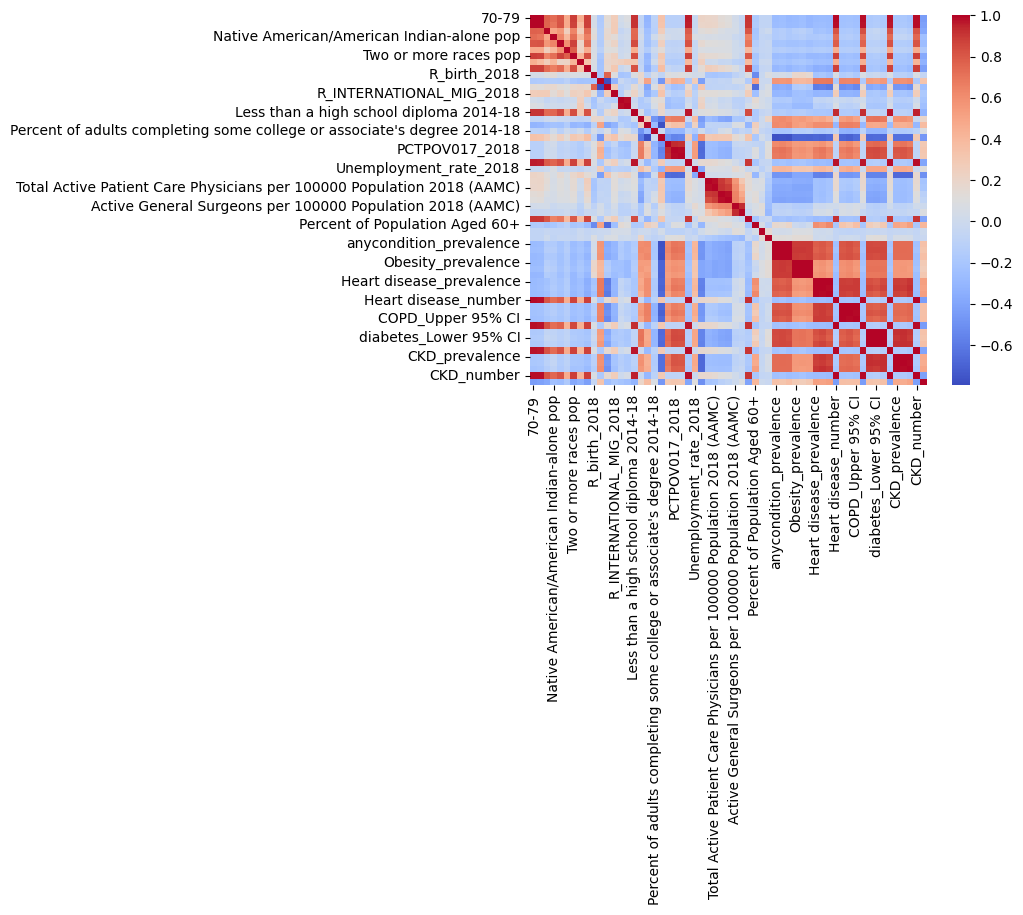

In [456]:
df_num = total_data.select_dtypes(include="number")
sns.heatmap(df_num.corr(), cmap="coolwarm")

Para nuestra variable podemos observar que hay relacionas directas con otras variables lo que nos indica existencia de multicolinealidad. Se podria aplicar técnicas de regularización con regresión ridge y lasso 

In [457]:
corr_target = df[num_cols].corr()[target].sort_values(ascending=False)
corr_target

Obesity_prevalence                                              1.000000
Obesity_Upper 95% CI                                            0.998239
Obesity_Lower 95% CI                                            0.998117
anycondition_Lower 95% CI                                       0.895747
anycondition_prevalence                                         0.894438
                                                                  ...   
CI90UBINC_2018                                                 -0.589779
Median_Household_Income_2018                                   -0.598189
MEDHHINC_2018                                                  -0.598189
CI90LBINC_2018                                                 -0.602412
Percent of adults with a bachelor's degree or higher 2014-18   -0.696026
Name: Obesity_prevalence, Length: 106, dtype: float64

In [458]:
total_data

,70-79,80+,Black-alone pop,Native American/American Indian-alone pop,Asian-alone pop,Hawaiian/Pacific Islander-alone pop,Two or more races pop,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,4050,2014,10915,267,681,62,1016,158,455,11.8,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,20936,9368,19492,1684,2508,146,3891,5403,2190,10.5,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,2244,1048,12042,164,113,46,307,-277,2820,10.4,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1723,785,4770,98,53,26,242,-155,2151,11.1,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,4931,2335,950,378,185,70,801,13,489,11.8,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,2198,949,592,665,435,68,894,-496,660,12.6,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,1569,657,175,211,326,35,363,-180,270,9.9,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,1233,507,168,288,96,30,361,-157,220,13.5,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,741,452,40,143,65,8,179,-150,140,9.3,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [459]:
df_dummies

,70-79,80+,Black-alone pop,Native American/American Indian-alone pop,Asian-alone pop,Hawaiian/Pacific Islander-alone pop,Two or more races pop,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,...,STATE_NAME_South Dakota,STATE_NAME_Tennessee,STATE_NAME_Texas,STATE_NAME_Utah,STATE_NAME_Vermont,STATE_NAME_Virginia,STATE_NAME_Washington,STATE_NAME_West Virginia,STATE_NAME_Wisconsin,STATE_NAME_Wyoming
0,4050,2014,10915,267,681,62,1016,158,455,11.8,...,False,False,False,False,False,False,False,False,False,False
1,20936,9368,19492,1684,2508,146,3891,5403,2190,10.5,...,False,False,False,False,False,False,False,False,False,False
2,2244,1048,12042,164,113,46,307,-277,2820,10.4,...,False,False,False,False,False,False,False,False,False,False
3,1723,785,4770,98,53,26,242,-155,2151,11.1,...,False,False,False,False,False,False,False,False,False,False
4,4931,2335,950,378,185,70,801,13,489,11.8,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,2198,949,592,665,435,68,894,-496,660,12.6,...,False,False,False,False,False,False,False,False,False,True
3136,1569,657,175,211,326,35,363,-180,270,9.9,...,False,False,False,False,False,False,False,False,False,True
3137,1233,507,168,288,96,30,361,-157,220,13.5,...,False,False,False,False,False,False,False,False,False,True
3138,741,452,40,143,65,8,179,-150,140,9.3,...,False,False,False,False,False,False,False,False,False,True


## Hacemos el train y split

In [460]:
# 1. Definir Target
target = 'Obesity_prevalence'

# 2. Identificar columnas de fuga (Leakage)
# Eliminamos las que contienen "Obesity" en el nombre excepto nuestro target
leakage_cols = [col for col in total_data.columns if 'Obesity' in col and col != target]

# 3. Identificar columnas no numéricas o IDs
id_cols = [ 'CNTY_FIPS', 'STATE_FIPS']

# 4. Limpieza final: Solo números y sin fugas
df_model = total_data.drop(columns=leakage_cols + id_cols)
df_model = df_model.select_dtypes(include=[np.number]).dropna()

X = df_model.drop(columns=[target])
y = df_model[target]

In [461]:
#X = total_data.drop("Obesity_prevalence", axis = 1)
#y= total_data["Obesity_prevalence"] 

In [462]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train

,70-79,80+,Black-alone pop,Native American/American Indian-alone pop,Asian-alone pop,Hawaiian/Pacific Islander-alone pop,Two or more races pop,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
1292,2460,1208,337,428,89,11,447,167,303,11.3,...,2314,13.7,12.6,14.9,2823,3.8,3.5,4.1,771,6
2302,4801,2928,593,109,231,22,649,-557,1302,9.7,...,4097,13.1,11.9,14.2,5416,3.5,3.2,3.8,1454,5
761,2713,1561,1435,135,394,18,549,169,5022,10.7,...,2792,12.2,11.2,13.1,3698,2.9,2.7,3.1,871,2
2194,6736,3478,1175,12403,1370,79,7741,505,1216,10.6,...,5716,11.2,10.4,12.0,7913,3.0,2.8,3.2,2118,3
1241,10074,6039,15004,1047,4026,61,4721,129,4326,12.0,...,10002,12.5,11.7,13.4,12987,3.4,3.2,3.6,3490,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092,2641,1328,370,230,532,18,638,572,2777,9.1,...,1914,8.0,7.3,8.7,2699,2.5,2.3,2.7,838,2
1095,2919,1271,3078,200,733,25,1115,1241,1091,12.5,...,3631,11.1,10.2,12.0,4670,2.6,2.4,2.8,1094,3
1130,2322,1170,9414,148,170,6,439,-182,1379,14.0,...,3111,16.0,15.0,16.9,3999,4.0,3.8,4.3,1013,6
1294,938,481,19,87,39,1,87,-80,83,5.3,...,661,16.1,14.6,17.7,816,4.5,4.2,5.0,229,6


In [463]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded
X_train_encoded

,70-79,80+,Black-alone pop,Native American/American Indian-alone pop,Asian-alone pop,Hawaiian/Pacific Islander-alone pop,Two or more races pop,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
1292,2460,1208,337,428,89,11,447,167,303,11.3,...,2314,13.7,12.6,14.9,2823,3.8,3.5,4.1,771,6
2302,4801,2928,593,109,231,22,649,-557,1302,9.7,...,4097,13.1,11.9,14.2,5416,3.5,3.2,3.8,1454,5
761,2713,1561,1435,135,394,18,549,169,5022,10.7,...,2792,12.2,11.2,13.1,3698,2.9,2.7,3.1,871,2
2194,6736,3478,1175,12403,1370,79,7741,505,1216,10.6,...,5716,11.2,10.4,12.0,7913,3.0,2.8,3.2,2118,3
1241,10074,6039,15004,1047,4026,61,4721,129,4326,12.0,...,10002,12.5,11.7,13.4,12987,3.4,3.2,3.6,3490,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092,2641,1328,370,230,532,18,638,572,2777,9.1,...,1914,8.0,7.3,8.7,2699,2.5,2.3,2.7,838,2
1095,2919,1271,3078,200,733,25,1115,1241,1091,12.5,...,3631,11.1,10.2,12.0,4670,2.6,2.4,2.8,1094,3
1130,2322,1170,9414,148,170,6,439,-182,1379,14.0,...,3111,16.0,15.0,16.9,3999,4.0,3.8,4.3,1013,6
1294,938,481,19,87,39,1,87,-80,83,5.3,...,661,16.1,14.6,17.7,816,4.5,4.2,5.0,229,6


In [464]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)   # fit solo en train
X_test_scaled = scaler.transform(X_test_encoded)          # transform en test

In [465]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [466]:
y_pred = model.predict(X_test_scaled)
y_pred

array([33.74809749, 30.95995046, 44.34363696, 31.66672378, 25.73472868,
       30.09287063, 34.24544021, 42.42096875, 32.81113576, 26.91597303,
       35.388787  , 35.82474761, 30.47862831, 38.3362362 , 31.23785133,
       35.89925027, 35.85233629, 36.77933221, 44.11099566, 30.19027499,
       39.70973989, 36.6353809 , 33.07954477, 38.07472823, 37.62996536,
       29.10115847, 20.51741281, 33.501902  , 33.2225524 , 42.20454108,
       42.60183675, 44.90384909, 34.37584604, 35.80019056, 30.32504269,
       39.98650659, 34.33439771, 30.05105267, 39.65298013, 31.25332153,
       40.8094983 , 36.63450219, 34.57190725, 35.6863948 , 32.31035618,
       39.04880908, 36.73166519, 32.10154063, 37.34457289, 39.94314229,
       31.36749169, 40.62249342, 30.72620659, 37.679291  , 35.72872848,
       44.10365788, 30.70072276, 36.8710435 , 36.79162593, 36.20121343,
       25.14129147, 34.17262741, 41.82039441, 27.50188203, 30.53694903,
       31.02660981, 38.11668788, 35.20253815, 33.1664093 , 34.23

In [467]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MAE: 1.2195
R²: 0.8860


# Nota: antes me habia dado un R2 de 0,99 por lo que habia claramente un data leak, por lo que he eliminado las columnas que tuvieran relacion con la variable cosa que no habia hecho antes 

In [468]:
alphas = np.logspace(-3, 3, 50)  # De 0.001 a 1000
lasso = Lasso(max_iter=10000)
grid_lasso = GridSearchCV(
    lasso, 
    {'alpha': alphas}, 
    cv=5, 
    scoring='r2'
)
grid_lasso.fit(X_train_scaled, y_train)

print(f"\nLasso - Mejor alpha: {grid_lasso.best_params_['alpha']:.4f}")
print(f"Lasso - Mejor R² (CV): {grid_lasso.best_score_:.4f}")

y_pred_lasso = grid_lasso.predict(X_test_scaled)
print(f"Lasso - R² Test: {r2_score(y_test, y_pred_lasso):.4f}")


Lasso - Mejor alpha: 0.0222
Lasso - Mejor R² (CV): 0.8757
Lasso - R² Test: 0.8792


El hecho de que el modelo Lineal (0.8860) y el Lasso (0.8792) tengan resultados casi idénticos indica que no hay un sobreajuste

# Conclusión


Tras corregir el problema de fuga de datos (data leakage) y eliminar variables redundantes, el modelo demuestra una alta fiabilidad. La regularización Lasso confirma que el modelo es estable, con un error promedio de solo 1.22%. Esto valida la hipótesis de que las condiciones demográficas y el nivel educativo de un condado son predictores determinantes de la salud metabólica de su población.

# Guardamos datos 

In [472]:
X_train.to_csv("../data/processed/X_train_demographic.csv", index=False)
X_test.to_csv("../data/processed/X_test_demographic.csv", index=False)

y_train.to_csv("../data/processed/y_train_demographic.csv", index=False)
y_test.to_csv("../data/processed/y_test_demographic.csv", index=False)